In [1]:
from superfv import HydroSolver, BC, ics, MUSCL_SlopeLimiter, RiemannSolver, HydroSolverOutput, SnapshotMode
import spd.initial_conditions as ic
from spd.sdfb_simulator import SPD_Simulator
import matplotlib as mpl
import matplotlib.pyplot as plt
from functools import partial
import os
import shutil

try:
    import cupy as cp
except ModuleNotFoundError:
    cp = None

mpl.rcParams["font.size"] = 15

In [2]:
if cp is None:
    print("cupy not available; running on CPU only")
else:
    for i in range(cp.cuda.runtime.getDeviceCount()):
        cp.cuda.runtime.setDevice(i)
        print([f"{round(x/1E9,2)}GB" for x in cp.cuda.runtime.memGetInfo()])

['41.51GB', '42.41GB']


In [3]:
base_directory = "/scratch/gpfs/jp7427/FVvsSD/rti/"

In [4]:
def run_superfv_sim(name, p, N, P0=1, **kwargs):
    path = base_directory + f"FV_{name}_{P0=}_{N=}_{p=}"

    try:
        out = HydroSolverOutput(path)
        print(f"Loaded output from '{path}'")
        return out
    except Exception as e:
        print(f"Failed to load output from '{path}' with: {e}")
        pass

    if os.path.exists(path):
        print(f"Removing bad output at '{path}'")
        shutil.rmtree(path)
    
    def gravity(idx, u, *, xp):
        gx = 0.0
        gy = 1.0
        out = xp.zeros_like(u)
        out[idx("mx")] = u[idx("rho")] * gx
        out[idx("my")] = u[idx("rho")] * gy
        out[idx("E")] = u[idx("mx")] * gx + u[idx("my")] * gy
        return out

    sim = HydroSolver(
        ic=partial(ics.rayleigh_taylor, gamma=5 / 3, P0=P0),
        gamma=5 / 3,
        rho_min=1e-10,
        P_min=1e-10,
        source=gravity,
        xlims=(0, 0.25),
        ylims=(0, 1),
        nx=N // 4,
        ny=N,
        bcy=(BC.REFLECTIVE, BC.REFLECTIVE),
        p=p,
        use_MOOD=True,
        use_NAD=True,
        use_SED=True,
        blend_troubles=False,
        MUSCL_limiter=MUSCL_SlopeLimiter.MONCEN,
        cupy=True,
        output_path=path,
        **kwargs,
    )
    sim.run(1.95)
    return sim

In [5]:
def run_spd_sim(name, p, N, P0=1, **kwargs):
    path = base_directory + f"SD_{name}_{P0=}_{N=}_{p=}"
    
    sim = SPD_Simulator(
        p=p,
        N=(N // 4, N),
        xlim=(0.0, 0.25),
        ylim=(0.0, 1.0),
        BC=(
            ("periodic", "periodic"),  # x
            ("reflective", "reflective"),  # y
        ),
        init_fct=ic.RTI(P0=1, gamma=5 / 3),
        gamma=5 / 3,
        cfl_coeff=0.4,
        use_cupy=True,
        time_integrator="rk3",
        fallback="MUSCL",
        slope_limiter="moncen",
        scheme="SDFB",
        potential=True,
        NAD="",
        PAD=True,
        SED=True,
        blending=False,
        riemann_solver_fv="hllc",  # MUSCL fallback flux
        folder=path,
        **kwargs,
    )

    try:
        sim.load_output()
        print(f"Loaded output from '{path}'")
        return sim
    except Exception as e:
        print(f"Failed to load output from '{path}' with: {e}")
        pass

    sim.perform_time_evolution(1.95)
    sim.output()
    return sim
        

In [6]:
def plot_fv(ax, sim):
    ax.set_aspect("equal")

    x_fv, y_fv, _ = sim.mesh.faces
    z_fv = sim.snapshot_history[-1].w[0, :, :, 0].T
    return ax.pcolormesh(cp.asnumpy(x_fv), cp.asnumpy(y_fv), z_fv)


def plot_sd(ax, sim):
    ax.set_aspect("equal")

    x_sd = sim.regular_faces()[0]
    y_sd = sim.regular_faces()[1]
    z_sd = sim.transpose_to_fv(sim.regular_mesh(sim.dm.W_cv))[0]
    return ax.pcolormesh(x_sd, y_sd, z_sd)

In [7]:
NDOF = 192 * 2
p = 3
N = NDOF // (p + 1)

In [8]:
s1 = run_superfv_sim("rtol=1e-1", p, NDOF, P0=1, rtol=1e-1)
s2 = run_superfv_sim("rtol=1e-2", p, NDOF, P0=1, rtol=1e-2)
s3 = run_superfv_sim("rtol=1e-3", p, NDOF, P0=1, rtol=1e-3)
s4 = run_superfv_sim("rtol=1e-4", p, NDOF, P0=1, rtol=1e-4)
s5 = run_superfv_sim("rtol=1e-5", p, NDOF, P0=1, rtol=1e-5)
s6 = run_superfv_sim("rtol=0", p, NDOF, P0=1, rtol=0)

Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_rtol=1e-1_P0=1_N=384_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_rtol=1e-2_P0=1_N=384_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_rtol=1e-3_P0=1_N=384_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_rtol=1e-4_P0=1_N=384_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_rtol=1e-5_P0=1_N=384_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_rtol=0_P0=1_N=384_p=3'


In [9]:
s7 = run_spd_sim("rtol=1e-1", p, N, P0=1, limiting_variables=[0, 1, 2, 4], tolerance=1e-1, riemann_solver_sd="hllc")
s8 = run_spd_sim("rtol=1e-2", p, N, P0=1, limiting_variables=[0, 1, 2, 4], tolerance=1e-2, riemann_solver_sd="hllc")
s9 = run_spd_sim("rtol=1e-3", p, N, P0=1, limiting_variables=[0, 1, 2, 4], tolerance=1e-3, riemann_solver_sd="hllc")
s10 = run_spd_sim("rtol=1e-4", p, N, P0=1, limiting_variables=[0, 1, 2, 4], tolerance=1e-4, riemann_solver_sd="hllc")
s11 = run_spd_sim("rtol=1e-5", p, N, P0=1, limiting_variables=[0, 1, 2, 4], tolerance=1e-5, riemann_solver_sd="hllc")
s12 = run_spd_sim("rtol=0", p, N, P0=1, limiting_variables=[0, 1, 2, 4], tolerance=0.0, riemann_solver_sd="hllc")

Failed to load output from '/scratch/gpfs/jp7427/FVvsSD/rti/SD_rtol=1e-1_P0=1_N=96_p=3' with: /scratch/gpfs/jp7427/FVvsSD/rti/SD_rtol=1e-1_P0=1_N=96_p=3/outputs.out not found.
t=1.95, steps taken 8365, time taken 388.399, bzcps = 0.001
Failed to load output from '/scratch/gpfs/jp7427/FVvsSD/rti/SD_rtol=1e-2_P0=1_N=96_p=3' with: /scratch/gpfs/jp7427/FVvsSD/rti/SD_rtol=1e-2_P0=1_N=96_p=3/outputs.out not found.
t=1.95, steps taken 8094, time taken 376.396, bzcps = 0.001
Failed to load output from '/scratch/gpfs/jp7427/FVvsSD/rti/SD_rtol=1e-3_P0=1_N=96_p=3' with: /scratch/gpfs/jp7427/FVvsSD/rti/SD_rtol=1e-3_P0=1_N=96_p=3/outputs.out not found.
t=1.95, steps taken 7910, time taken 367.419, bzcps = 0.001
Failed to load output from '/scratch/gpfs/jp7427/FVvsSD/rti/SD_rtol=1e-4_P0=1_N=96_p=3' with: /scratch/gpfs/jp7427/FVvsSD/rti/SD_rtol=1e-4_P0=1_N=96_p=3/outputs.out not found.
t=1.95, steps taken 7824, time taken 361.67, bzcps = 0.001
Failed to load output from '/scratch/gpfs/jp7427/FVvsSD/r

-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_rtol=1e-1_P0=1_N=384_p=3/output_000001.pkl.
-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_rtol=1e-2_P0=1_N=384_p=3/output_000001.pkl.
-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_rtol=1e-3_P0=1_N=384_p=3/output_000001.pkl.
-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_rtol=1e-4_P0=1_N=384_p=3/output_000001.pkl.
-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_rtol=1e-5_P0=1_N=384_p=3/output_000001.pkl.
-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_rtol=0_P0=1_N=384_p=3/output_000001.pkl.


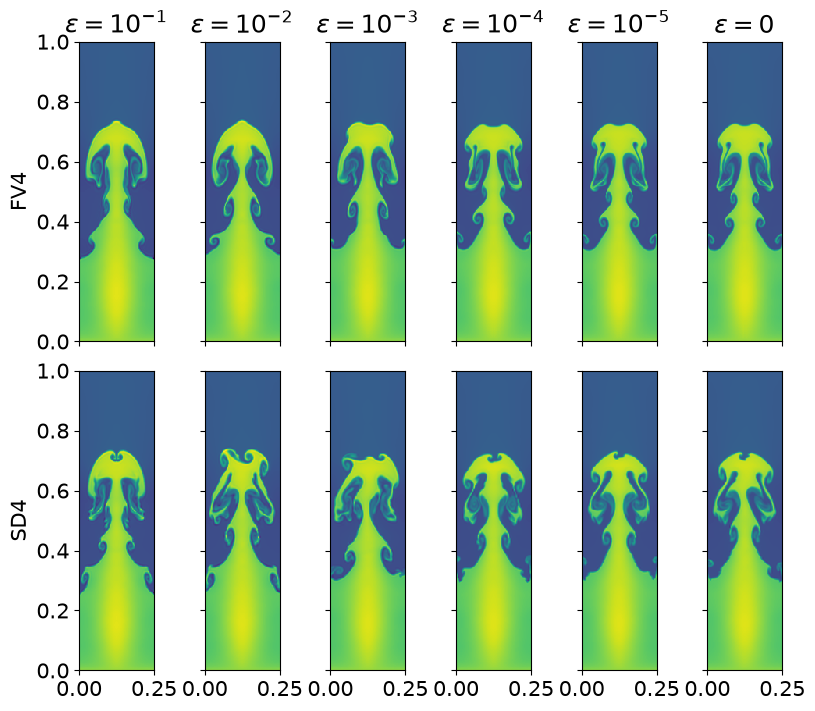

In [10]:
fig, axs = plt.subplots(2, 6, sharex=True, sharey=True, constrained_layout=True, figsize=(8, 7))
axs[0, 0].set_ylabel("FV4")
axs[1, 0].set_ylabel("SD4")
axs[0, 0].set_title(r"$\varepsilon=10^{-1}$")
axs[0, 1].set_title(r"$\varepsilon=10^{-2}$")
axs[0, 2].set_title(r"$\varepsilon=10^{-3}$")
axs[0, 3].set_title(r"$\varepsilon=10^{-4}$")
axs[0, 4].set_title(r"$\varepsilon=10^{-5}$")
axs[0, 5].set_title(r"$\varepsilon=0$")

meshes = []
for i, s in enumerate([s1, s2, s3, s4, s5, s6]):
    meshes.append(plot_fv(axs[0, i], s))
for i, s in enumerate([s7, s8, s9, s10, s11, s12]):
    meshes.append(plot_sd(axs[1, i], s))

vmin = min(m.get_array().min() for m in meshes)
vmax = max(m.get_array().max() for m in meshes)

for m in meshes:
    m.set_clim(vmin, vmax)

In [11]:
def gravity(idx, u, *, xp):
        gx = 0.0
        gy = 1.0
        out = xp.zeros_like(u)
        out[idx("mx")] = u[idx("rho")] * gx
        out[idx("my")] = u[idx("rho")] * gy
        out[idx("E")] = u[idx("mx")] * gx + u[idx("my")] * gy
        return out

sim = HydroSolver(
    ic=partial(ics.rayleigh_taylor, gamma=5 / 3, P0=1),
    gamma=5 / 3,
    rho_min=1e-10,
    P_min=1e-10,
    source=gravity,
    xlims=(0, 0.25),
    ylims=(0, 1),
    nx=NDOF // 4,
    ny=NDOF,
    bcy=(BC.REFLECTIVE, BC.REFLECTIVE),
    p=p,
    use_MOOD=False,
    use_NAD=True,
    use_SED=True,
    blend_troubles=False,
    MUSCL_limiter=MUSCL_SlopeLimiter.MONCEN,
    riemann_solver=RiemannSolver.LLF,
    cupy=True,
)
sim.take_n_steps(10, snapshot_mode=SnapshotMode.NONE)

SuperFV: step 10/10 | dt=5.07e-04 | rho_min=9.34e-01 | E_cons=7.48e-04 | wall=1.05e-01s (done)


In [12]:
sim = SPD_Simulator(
    p=p,
    N=(N // 4, N),
    xlim=(0.0, 0.25),
    ylim=(0.0, 1.0),
    BC=(
        ("periodic", "periodic"),  # x
        ("reflective", "reflective"),  # y
    ),
    init_fct=ic.RTI(P0=1, gamma=5 / 3),
    cfl_coeff=0.4,
    use_cupy=True,
    time_integrator="rk3",
    fallback="MUSCL",
    slope_limiter="moncen",
    scheme="SD",
    FB=False,
    potential=True,
    NAD="",
    PAD=True,
    SED=True,
    blending=False,
    riemann_solver_sd="llf",  # MUSCL fallback flux
)
sim.perform_iterations(10)

t=0.002762554644883207, steps taken 10, time taken 0.097, bzcps = 0.004
